# Các Mô Hình Học Không Giám Sát cho Phát Hiện Xâm Nhập Dựa Trên Bất Thường

Jupyter Notebook này tập trung vào việc huấn luyện và đánh giá các mô hình học máy không giám sát cho phát hiện xâm nhập dựa trên bất thường. Nó được xây dựng dựa trên tập dữ liệu CICIDS2017 đã được tiền xử lý

**Các Mô Hình Được Đánh Giá:**

* **Học Có Giám Sát:**
    * Random Forest
    * XGBoost
    * _k_-NN

* **Học Không Giám Sát (Notebook Này):**
    * Isolation Forest
    * K-means

In [ ]:
# Cài đặt các thành phần bổ sung
!pip install memory_profiler
!pip install psutil

In [ ]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, davies_bouldin_score, calinski_harabasz_score

import time
import psutil
import threading
from memory_profiler import memory_usage

import joblib

# Các Hàm Hỗ Trợ

In [ ]:
# Áp dụng Isolation Forest với đo lường tài nguyên
def apply_if(X_train, y_train=None, best_params=None, random_state=42, n_jobs=-1):

    measurement_if = {}

    # Mặc định là dictionary rỗng nếu best_params không được cung cấp
    best_params = best_params or {}

    if_model = IsolationForest(**best_params, random_state=random_state, n_jobs=n_jobs)
    
    # Hàm để giám sát việc sử dụng CPU trong quá trình huấn luyện
    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    # Hàm để huấn luyện mô hình
    def train_model():
        if_model.fit(X_train)

    try:
        # Bắt đầu giám sát CPU trong một luồng riêng biệt
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        # Đo lường việc sử dụng bộ nhớ và thời gian huấn luyện
        start_time = time.time()
        train_memory_if = max(memory_usage((train_model,)))  # Đo lường mức sử dụng bộ nhớ đỉnh
        training_time = time.time() - start_time

        # Dừng giám sát CPU
        stop_flag.set()
        cpu_thread.join()

        # Thêm các đo lường
        measurement_if['Memory Usage (MB)'] = train_memory_if
        measurement_if['Training Time (s)'] = training_time
        measurement_if['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_if['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement_if, if_model

    except Exception as e:
        print(f"Error during Isolation Forest training: {e}")
        return None, None

In [ ]:
# Áp dụng K-means với đo lường tài nguyên
def apply_kmeans(X, n_clusters=7, random_state=42, n_init='auto'):

    measurement_kmeans = {}
    
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)

    # Hàm để giám sát việc sử dụng CPU trong quá trình huấn luyện
    cpu_usage = []
    stop_flag = threading.Event()
    
    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))
    
    # Hàm để huấn luyện mô hình
    def train_model():
        kmeans_model.fit(X)
    
    try:
        # Bắt đầu giám sát CPU trong một luồng riêng biệt
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()
        
        # Đo lường việc sử dụng bộ nhớ và thời gian huấn luyện
        start_time = time.time()
        train_memory_kmeans = max(memory_usage((train_model,)))  # Đo lường mức sử dụng bộ nhớ đỉnh
        training_time = time.time() - start_time
        
        # Dừng giám sát CPU
        stop_flag.set()
        cpu_thread.join()
        
        # Thêm các đo lường
        measurement_kmeans['Memory Usage (MB)'] = train_memory_kmeans
        measurement_kmeans['Training Time (s)'] = training_time
        measurement_kmeans['Peak CPU Usage (%)'] = max(cpu_usage)
        measurement_kmeans['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0
        
        # Lấy nhãn cluster
        labels = kmeans_model.labels_
        
        return kmeans_model, labels, measurement_kmeans
    
    except Exception as e:
        print(f"Error during K-Means training: {e}")
        return None, None, None

In [ ]:
# Tìm số lượng cluster tối ưu cho K-Means
def find_optimal_k(X, k_range, random_state=42, n_init=10):

    results = {
        'k_values': list(k_range),
        'inertia': [],
        'davies_bouldin': [],
        'calinski_harabasz': []
    }
    
    for k in k_range:
        print(f"Testing with k={k}...")
        # Huấn luyện K-Means
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        kmeans.fit(X)
        labels = kmeans.labels_
        
        # Tính toán các số liệu
        results['inertia'].append(kmeans.inertia_)
        results['davies_bouldin'].append(davies_bouldin_score(X, labels))
        results['calinski_harabasz'].append(calinski_harabasz_score(X, labels))
    
    return results

# 1. Chuẩn Bị Dữ Liệu: Chia Test/Train và Scaling

In [ ]:
# Tải tập dữ liệu
clean_df = pd.read_csv('/kaggle/input/cicids2017_cleaned.csv')

In [ ]:
# Chuẩn bị các đặc trưng và nhãn thực tế
X = clean_df.drop('Attack Type', axis=1)
y = clean_df['Attack Type']

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 1.1 Chuẩn Hóa Đặc Trưng

Chuẩn hóa các đặc trưng bằng `RobustScaler` đảm bảo rằng mô hình không bị ảnh hưởng không cân xứng bởi các đặc trưng có độ lớn lớn hơn hoặc các giá trị ngoại lai cực đoan, điều này đặc biệt quan trọng cho các thuật toán phát hiện bất thường dựa trên khoảng cách. Lựa chọn phương pháp này đã được thảo luận trong [notebook trước](https://www.kaggle.com/code/ericanacletoribeiro/cicids2017-ml-models-comparison-supervised).

In [ ]:
# Khởi tạo RobustScaler
scaler = RobustScaler()

# Fit và transform dữ liệu huấn luyện
X_train_scaled = scaler.fit_transform(X_train)

# Transform tập kiểm tra và validation bằng scaler đã fit
X_test_scaled = scaler.transform(X_test)

| **Mô hình**                  | **Scaling Có Quan Trọng?** | **Giải thích**                                                                 |
|----------------------------|---------------------------|---------------------------------------------------------------------------------|
| **K-Means Clustering**     | Có                       | K-Means dựa vào các số liệu khoảng cách để hình thành các cluster; các đặc trưng không được chuẩn hóa có thể chi phối quá trình phân cụm, dẫn đến kết quả sai lệch hoặc không chính xác. |
| **Isolation Forest**       | Không                        | Isolation Forest sử dụng cấu trúc dựa trên cây, không nhạy cảm với việc chuẩn hóa đặc trưng. Nó cô lập các bất thường mà không dựa vào các số liệu khoảng cách, vì vậy scaling không quan trọng. |

In [ ]:
# Xuất scaler trong trường hợp cần thiết trong quá trình triển khai
joblib.dump(scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

## 1.2 Phân Loại Nhị Phân

Đối với **học không giám sát**, một lựa chọn phổ biến là khám phá **cách tiếp cận nhị phân**, thường liên quan đến việc chuyển đổi vấn đề đa lớp thành vấn đề **bình thường vs. bất thường (tấn công)** đơn giản hơn. Điều này đặc biệt hữu ích trong các tình huống như **phát hiện bất thường**, nơi mục tiêu là phân biệt giữa các mẫu bình thường và bất kỳ hình thức lệch lạc nào (có thể đại diện cho các cuộc tấn công tiềm ẩn hoặc hành vi bất thường).

| **Thuật toán**       | **Tốt hơn với Cách Tiếp Cận Nhị Phân?** | **Tại sao?**                                                                                          |
|---------------------|----------------------------------|--------------------------------------------------------------------------------------------------|
| **K-Means**          |  Có                           | K-Means có thể gặp khó khăn với nhiều lớp tấn công vì nó xử lý tất cả các cluster như nhau. Cách tiếp cận nhị phân đơn giản hóa vấn đề, vì nó tập trung vào việc phân biệt lưu lượng bình thường với tất cả các loại bất thường, giảm độ phức tạp của việc diễn giải cluster. |
| **Isolation Forest** | Có                           | Isolation Forest hoạt động tốt với cách tiếp cận nhị phân vì nó được thiết kế để cô lập các bất thường. Xử lý các cuộc tấn công như bất thường (so với lưu lượng bình thường) đơn giản hóa vấn đề, cải thiện khả năng phát hiện bất thường của mô hình. Đa lớp sẽ yêu cầu nó phân tách nhiều loại tấn công, làm phức tạp nhiệm vụ. |

In [ ]:
# Đơn giản hóa biến mục tiêu thành hai lớp cho tập huấn luyện
y_train_bin = y_train.apply(lambda x: 1 if x != 'Normal Traffic' else 0)

# Đơn giản hóa biến mục tiêu thành hai lớp cho tập kiểm tra
y_test_bin = y_test.apply(lambda x: 1 if x != 'Normal Traffic' else 0)

In [ ]:
# Kiểm tra biến mục tiêu
print(y_train_bin.value_counts())
print(y_test_bin.value_counts())

Attack Type
0    1466539
1     297986
Name: count, dtype: int64
Attack Type
0    628518
1    127708
Name: count, dtype: int64


In [ ]:
# Dọn dẹp
del X, y, clean_df

**Các tập cuối cùng cho huấn luyện và đánh giá**

*Đã Chuẩn Hóa:*
- X_train_scaled, y_train
- X_test_scaled, y_test

*Raw*
- X_train, y_train
- X_test, y_test

*Lớp nhị phân*
- y_train_bin
- y_test_bin

# 2. Học Không Giám Sát

## 2.1 Isolation Forest
Isolation Forest là một thuật toán phát hiện bất thường cô lập các quan sát bằng cách chọn ngẫu nhiên một đặc trưng và sau đó chọn ngẫu nhiên một giá trị phân tách giữa giá trị tối đa và tối thiểu của đặc trưng đã chọn. Việc cô lập này được thực hiện đệ quy.

Isolation Forest hữu ích vì:
1. Nó xác định rõ ràng các bất thường (các cuộc tấn công tiềm ẩn) thay vì hành vi bình thường
2. Nó hiệu quả với dữ liệu có chiều cao
3. Nó hoạt động tốt khi các bất thường là các sự kiện hiếm trong tập dữ liệu

### 2.1.1. Điều Chỉnh Tham Số

Không giống như học có giám sát, điều chỉnh siêu tham số cho Isolation Forest khó khăn hơn vì chúng ta không sử dụng nhãn trong quá trình huấn luyện. Tuy nhiên, chúng ta vẫn có thể tối ưu hóa các tham số bằng cách đo lường mức độ phù hợp của điểm bất thường của mô hình với các nhãn đã biết của chúng ta.

**Noise của tập huấn luyện**

- Lưu lượng bình thường: 1466539
- Tấn công: 297986

$$
\frac{297986 \times 100}{1466539 + 297986} = \frac{29798600}{1764525} \approx 16.89\%
$$

In [ ]:
# Định nghĩa các tham số cho Isolation Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': [256, 512, 'auto'],
    'contamination': [0.169], # Contamination được tính dựa trên tỷ lệ thực tế của các cuộc tấn công trong tập huấn luyện.
    'max_features': [0.5, 0.7, 1.0]
}

**Vì học không giám sát không có nhãn mục tiêu, cần phải code một hàm đánh giá tùy chỉnh để sử dụng RandomSearchCV để so sánh hiệu suất trong một phạm vi các siêu tham số được xác định trước.**

In [ ]:
# Hàm scoring tùy chỉnh để sử dụng cho điều chỉnh tham số
def custom_score(estimator, X, y, contamination=0.169):

    anomaly_scores = estimator.decision_function(X)
    threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))  # Đặt ngưỡng tùy chỉnh dựa trên tỷ lệ nhiễm
    
    y_pred = (anomaly_scores <= threshold).astype(int)
    
    # Tính F1-score cho lớp dương (Attack) bằng cách sử dụng binary averaging
    return f1_score(y, y_pred, pos_label=1, average='binary')

In [ ]:
# Thiết lập RandomizedSearchCV
if_model = IsolationForest(random_state=42, n_jobs=-1)
random_search_if = RandomizedSearchCV(
    estimator=if_model, 
    param_distributions=param_grid, 
    n_iter=27, # tổng số lần lặp có thể dựa trên lưới tham số
    scoring=custom_score,
    cv=2, # ít liên quan hơn cho học không giám sát
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [ ]:
# Sử dụng nhãn nhị phân cho điều chỉnh
random_search_if.fit(X_train, y_train_bin)

Fitting 2 folds for each of 27 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


RandomizedSearchCV(cv=2, estimator=IsolationForest(n_jobs=-1, random_state=42),
                   n_iter=27, n_jobs=-1,
                   param_distributions={'contamination': [0.169],
                                        'max_features': [0.5, 0.7, 1.0],
                                        'max_samples': [256, 512, 'auto'],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42,
                   scoring=<function custom_score at 0x7a3e181275b0>,
                   verbose=2)

In [ ]:
print(f'Best Parameters: {random_search_if.best_params_}')
print(f'Best Score: {random_search_if.best_score_}')

best_params_if = random_search_if.best_params_

del random_search_if

Best Parameters: {'n_estimators': 200, 'max_samples': 512, 'max_features': 1.0, 'contamination': 0.169}
Best Score: 0.3377656935422071


**Lưu Ý về Điều Chỉnh Siêu Tham Số**

Do tính chất ngẫu nhiên của RandomizedSearchCV, các giá trị cho mỗi tham số có thể khác nhau mỗi khi notebook này được chạy. 
Các tham số tốt nhất đã chọn là:
- n_estimators: 200
- max_samples: 512
- contamination: 0.169
- max_features: 1.0

Nếu bạn muốn tái tạo kết quả của tôi, đây là các tham số đã cung cấp hiệu suất tối ưu cho mô hình này.

### 2.1.2 Fitting Isolation Forest

In [ ]:
# Huấn luyện mô hình với phân loại nhị phân
measurement_if, if_model = apply_if(X_train, best_params=best_params_if)

# Lấy điểm bất thường cho tập kiểm tra (cao hơn = có khả năng bất thường hơn)
anomaly_scores = -if_model.decision_function(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [ ]:
# Tính đường cong ROC để xác định ngưỡng tối ưu cho phân loại nhị phân
fpr, tpr, thresholds = roc_curve(y_test_bin, anomaly_scores)

# Chọn ngưỡng nơi TPR - FPR được tối đa hóa (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Phân loại các bất thường
y_pred_if = (anomaly_scores >= optimal_threshold).astype(int)

In [ ]:
# Đánh giá hiệu suất mô hình so với nhãn thực tế
accuracy_if_binary = accuracy_score(y_test_bin, y_pred_if)
precision_if_binary = precision_score(y_test_bin, y_pred_if)
recall_if_binary = recall_score(y_test_bin, y_pred_if)
f1_if_binary = f1_score(y_test_bin, y_pred_if)

print(f'Binary Classification Metrics:')
print(f'Accuracy: {accuracy_if_binary:.4f}')
print(f'Precision: {precision_if_binary:.4f}')
print(f'Recall: {recall_if_binary:.4f}')
print(f'F1-Score: {f1_if_binary:.4f}')

Binary Classification Metrics:
Accuracy: 0.7781
Precision: 0.3972
Recall: 0.6064
F1-Score: 0.4800


In [ ]:
# Kiểm tra chi phí tính toán
print("Đo lường tài nguyên:", measurement_if)

Resource measurements: {'Memory Usage (MB)': 3538.82421875, 'Training Time (s)': 142.1897075176239, 'Peak CPU Usage (%)': 90.0, 'Average CPU Usage (%)': 27.87191489361693}


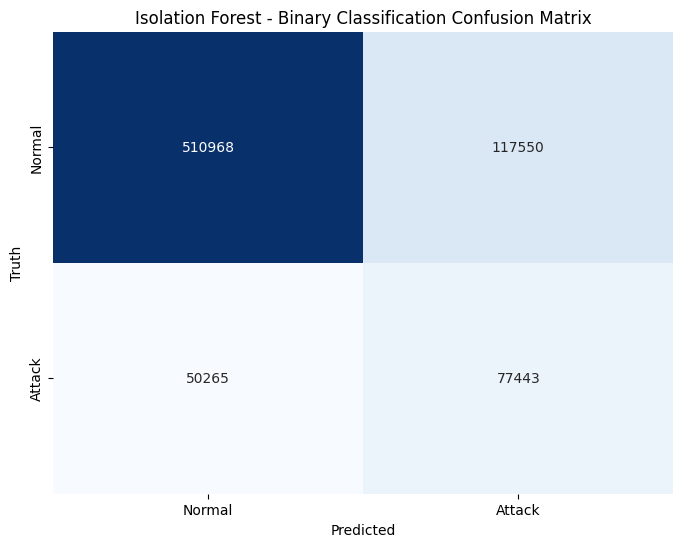

In [ ]:
# Confusion Matrix cho Phân Loại Nhị Phân
cm_if_binary = confusion_matrix(y_test_bin, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_if_binary, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - Binary Classification Confusion Matrix')
plt.show()

In [ ]:
# Báo cáo phân loại
print(classification_report(y_test_bin, y_pred_if, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.91      0.81      0.86    628518
      Attack       0.40      0.61      0.48    127708

    accuracy                           0.78    756226
   macro avg       0.65      0.71      0.67    756226
weighted avg       0.82      0.78      0.79    756226



**Lấy kết quả được thu thập bởi Sirisha et al. (2021) làm điểm chuẩn, đây là cách IF được huấn luyện ở đây so sánh:**

| **Mô hình**            | **Accuracy** | **Precision (Normal)** | **Precision (Anomaly)** | **Recall (Normal)** | **Recall (Anomaly)** | **F1 Score (Normal)** | **F1 Score (Anomaly)** |
|----------------------|--------------|------------------------|-------------------------|---------------------|----------------------|-----------------------|------------------------|
| **Tham chiếu (IF)**   | 0.79         | 0.45                   | 0.83                    | 0.23                | 0.93                 | 0.30                  | 0.88                   |
| **IF (notebook này)**          | 0.78         | 0.91                   | 0.40                    | 0.81                | 0.61                 | 0.86                  | 0.48        |

### 2.1.3 Xuất Mô Hình

In [ ]:
# Lưu mô hình vào file
joblib.dump(if_model, 'isolation_forest.joblib')

['isolation_forest.joblib']

## 2.2. K-means

In [ ]:
# Tìm k tối ưu
k_range = range(2, 15)
results = find_optimal_k(X_train_scaled, k_range)

Testing with k=2...
Testing with k=3...
Testing with k=4...
Testing with k=5...
Testing with k=6...
Testing with k=7...
Testing with k=8...
Testing with k=9...
Testing with k=10...
Testing with k=11...
Testing with k=12...
Testing with k=13...
Testing with k=14...


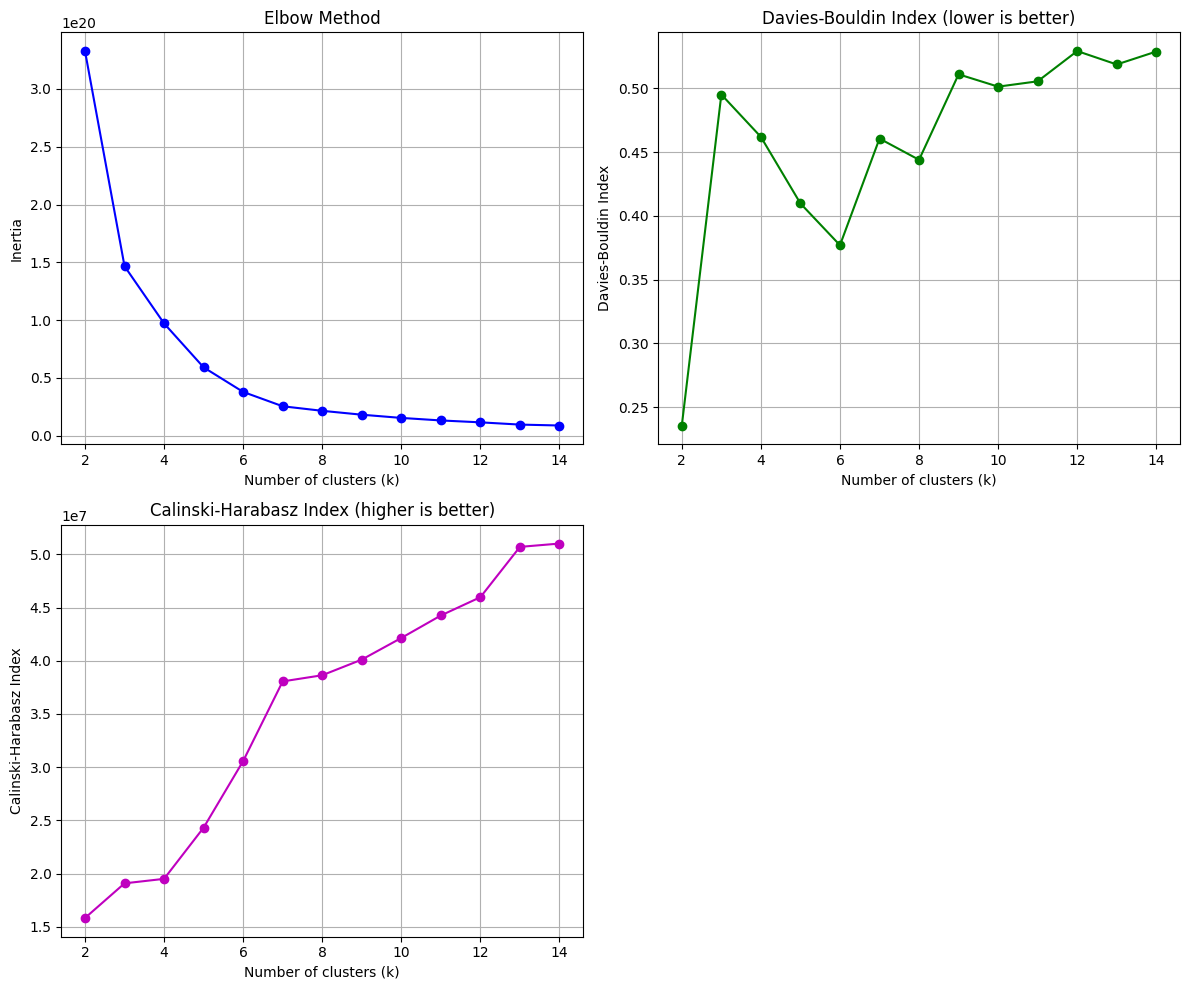

In [ ]:
# Vẽ kết quả
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Vẽ inertia (phương pháp Elbow)
axes[0, 0].plot(results['k_values'], results['inertia'], 'bo-')
axes[0, 0].set_xlabel('Number of clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

# Vẽ Davies-Bouldin index
axes[0, 1].plot(results['k_values'], results['davies_bouldin'], 'go-')
axes[0, 1].set_xlabel('Number of clusters (k)')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (lower is better)')
axes[0, 1].grid(True)

# Vẽ Calinski-Harabasz index
axes[1, 0].plot(results['k_values'], results['calinski_harabasz'], 'mo-')
axes[1, 0].set_xlabel('Number of clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index (higher is better)')
axes[1, 0].grid(True)

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()

### 2.2.2. Fitting Mô Hình K-means
Đối với K-means, chúng ta sẽ sử dụng các đặc trưng đã được chuẩn hóa vì đây là một thuật toán dựa trên khoảng cách.

In [ ]:
# Fitting mô hình
kmeans_model, cluster_labels, measurement_kmeans = apply_kmeans(X_train_scaled, n_clusters=3)

# Thực hiện dự đoán trên tập kiểm tra
test_cluster_labels = kmeans_model.predict(X_test_scaled)

In [ ]:
# Xác định Cluster "Normal"
cluster_counts = pd.Series(cluster_labels).value_counts()

# Giả sử cluster lớn nhất là "normal"
normal_cluster = cluster_counts.idxmax()

In [ ]:
# Gán "0" cho cluster bình thường và "1" cho tất cả các cluster khác
y_pred_kmeans = (test_cluster_labels != normal_cluster).astype(int)

In [ ]:
# Đánh giá chi phí tính toán
print("Đo lường tài nguyên:", measurement_kmeans)

Resource measurements: {'Memory Usage (MB)': 3952.8828125, 'Training Time (s)': 3.017977476119995, 'Peak CPU Usage (%)': 100.0, 'Average CPU Usage (%)': 62.00666666666667}


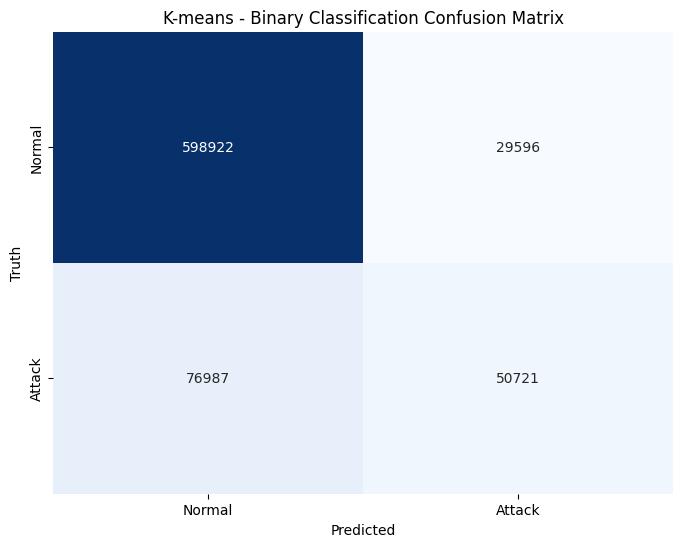

In [ ]:
# Confusion Matrix cho Phân Loại Nhị Phân
cm_kmeans = confusion_matrix(y_test_bin, y_pred_kmeans)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('K-means - Binary Classification Confusion Matrix')
plt.show()

In [ ]:
# Báo cáo phân loại
print(classification_report(y_test_bin, y_pred_kmeans, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92    628518
      Attack       0.63      0.40      0.49    127708

    accuracy                           0.86    756226
   macro avg       0.76      0.68      0.70    756226
weighted avg       0.84      0.86      0.85    756226



**Lấy kết quả được thu thập bởi Sirisha et al. (2021) làm điểm chuẩn, đây là cách mô hình K-Means được huấn luyện ở đây so sánh:**

| **Mô hình**            | **Accuracy** | **Precision (Normal)** | **Precision (Anomaly)** | **Recall (Normal)** | **Recall (Anomaly)** | **F1 Score (Normal)** | **F1 Score (Anomaly)** | 
|----------------------|--------------|------------------------|-------------------------|---------------------|----------------------|-----------------------|------------------------|
| **Tham chiếu (K-Means)** | 0.79         | 0.84                   | 0.46                    | 0.91                | 0.31                 | 0.88                  | 0.37                   |
| **K-Means (notebook này)**      | 0.86         | 0.89                   | 0.63                    | 0.95                | 0.40                 | 0.92                  | 0.49                   |

### 2.2.3. Xuất Mô Hình

In [ ]:
# Lưu mô hình và scaler vào file
joblib.dump(kmeans_model, 'kmeans_model.joblib')

['kmeans_model.joblib']

# 3. So Sánh Kết Quả Hiệu Suất

In [ ]:
# Tính toán precision, recall và F1 score cho mỗi mô hình không giám sát
precision_if = precision_score(y_test_bin, y_pred_if, average='weighted')
recall_if = recall_score(y_test_bin, y_pred_if, average='weighted')
f1_if = f1_score(y_test_bin, y_pred_if, average='weighted')
accuracy_if = accuracy_score(y_test_bin, y_pred_if)

precision_kmeans = precision_score(y_test_bin, y_pred_kmeans, average='weighted')
recall_kmeans = recall_score(y_test_bin, y_pred_kmeans, average='weighted')
f1_kmeans = f1_score(y_test_bin, y_pred_kmeans, average='weighted')
accuracy_kmeans = accuracy_score(y_test_bin, y_pred_kmeans)

In [ ]:
# Tạo dataframe kết quả
unsupervised_results = pd.DataFrame({
    'Model': ['Isolation Forest', 'K-Means'],
    'Accuracy': [accuracy_if, accuracy_kmeans],
    'Precision': [precision_if, precision_kmeans],
    'Recall': [recall_if, recall_kmeans],
    'F1 Score': [f1_if, f1_kmeans],
    'Memory Usage (MB)': [measurement_if['Memory Usage (MB)'], measurement_kmeans['Memory Usage (MB)']],
    'Training Time (s)': [measurement_if['Training Time (s)'], measurement_kmeans['Training Time (s)']],
    'Peak CPU Usage (%)': [measurement_if['Peak CPU Usage (%)'], measurement_kmeans['Peak CPU Usage (%)']],
    'Average CPU Usage (%)': [measurement_if['Average CPU Usage (%)'], measurement_kmeans['Average CPU Usage (%)']],
})

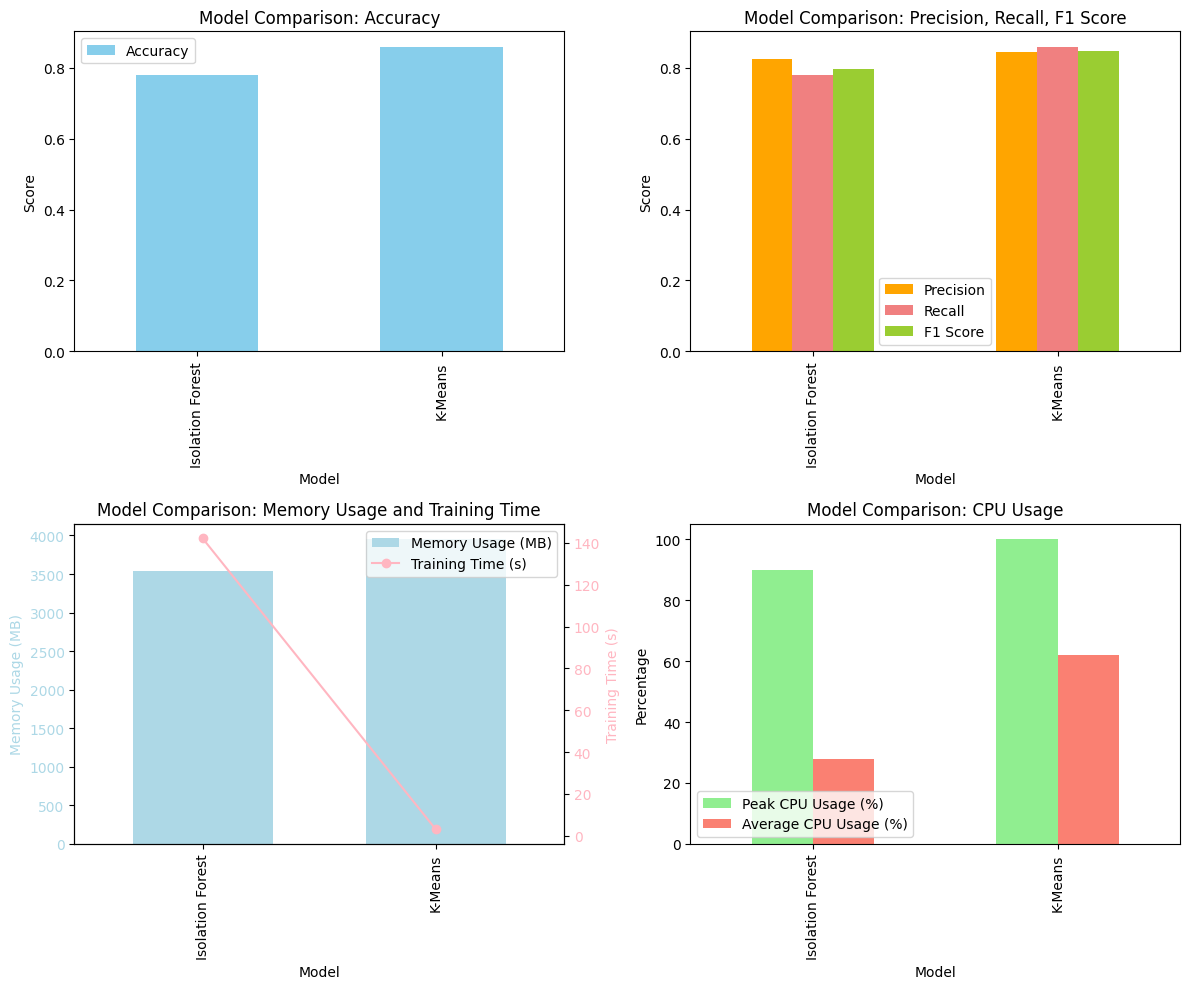

In [ ]:
# Vẽ so sánh cho accuracy, các số liệu và hiệu suất
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Vẽ Accuracy
unsupervised_results.set_index('Model')['Accuracy'].plot(kind='bar', ax=axes[0, 0], color='skyblue', legend=True)
axes[0, 0].set_title('Model Comparison: Accuracy')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xlabel('Model')

# Vẽ Precision, Recall, F1 Score
unsupervised_results.set_index('Model')[['Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=axes[0, 1], color=['orange', 'lightcoral', 'yellowgreen'], legend=True)
axes[0, 1].set_title('Model Comparison: Precision, Recall, F1 Score')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xlabel('Model')

# Vẽ Memory Usage và Training Time
ax1 = axes[1, 0]

unsupervised_results.set_index('Model')['Memory Usage (MB)'].plot(
    kind='bar', ax=ax1, color='lightblue', label='Memory Usage (MB)', width=0.6
)
ax1.set_ylabel('Memory Usage (MB)', color='lightblue')
ax1.tick_params(axis='y', labelcolor='lightblue')

ax2 = ax1.twinx() 
unsupervised_results.set_index('Model')['Training Time (s)'].plot(
    ax=ax2, color='lightpink', marker='o', label='Training Time (s)'
)
ax2.set_ylabel('Training Time (s)', color='lightpink')
ax2.tick_params(axis='y', labelcolor='lightpink')

ax1.set_title('Model Comparison: Memory Usage and Training Time')
ax1.set_xlabel('Model')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Vẽ Peak và Average CPU Usage
unsupervised_results.set_index('Model')[['Peak CPU Usage (%)', 'Average CPU Usage (%)']].plot(kind='bar', ax=axes[1, 1], color=['lightgreen', 'salmon'], legend=True)
axes[1, 1].set_title('Model Comparison: CPU Usage')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xlabel('Model')
axes[1, 1].legend(loc='lower left')

plt.tight_layout()
plt.show()